In [15]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore


THEME = 'BrBG'

Let  

$$
\mathbf{Y}_t = 
\begin{pmatrix}
\text{gurkor}_t \\
\text{guitars}_t \\
\text{slingshots}_t \\
\text{stocks}_t \\
\text{sugar}_t \\
\text{water}_t \\
\text{tranquillity}_t
\end{pmatrix}
\qquad
\mathbf{F}_t = 
\begin{pmatrix}
F0_t \\ F1_t \\ F2_t \\ F3_t \\ F4_t
\end{pmatrix}
$$

Then the data is generated as

$$
\mathbf{Y}_t = \Lambda \mathbf{F}_t + \mathbf{e}_t
$$

where $\Lambda$ is exactly the 7×5 loading matrix we computed:

$$
\Lambda = 
\begin{pmatrix}
-0.460493 & 0.431975 & 0.226305 & -0.218470 & -0.041653 \\
0.494112 & 0.212170 & 0.095774 & -0.260540 & -0.236640 \\
0.441043 & 0.204170 & 0.094476 & -0.485899 & -0.347878 \\
0.045350 & -0.378985 & 0.920457 & 0.082476 & -0.006300 \\
0.203079 & 0.539617 & 0.140728 & 0.759331 & -0.240474 \\
-0.469721 & 0.408214 & 0.206995 & -0.237389 & -0.099435 \\
0.292140 & 0.353894 & 0.144209 & -0.092477 & 0.868040
\end{pmatrix}
$$

$\mathbf{e}_t$ is idiosyncratic noise (diagonal covariance, very small for stocks and tranquillity).

The latent factors obey the VAR(2) that we fitted (constants ≈ 0):

$$
\mathbf{F}_t = \Phi_1 \mathbf{F}_{t-1} + \Phi_2 \mathbf{F}_{t-2} + \boldsymbol{\epsilon}_t
$$

with the exact coefficient matrices (not all factors are here)

**$\Phi_1$ (lag 1) key entries** (all others are small/insignificant):

- $F0_t$: $0.070 F0_{t-1} - 0.126 F3_{t-1} - 0.116 F4_{t-1}$
- $F1_t$: $0.124 F0_{t-1} + 0.033 F2_{t-1} - 0.266 F3_{t-1} - 0.076 F4_{t-1}$
- $F2_t$: $0.027 F0_{t-1}$
- $F3_t$: $0.198 F0_{t-1} - 0.222 F3_{t-1} - 0.061 F4_{t-1}$
- $F4_t$: $-0.033 F0_{t-1} - 0.032 F1_{t-1}$

**$\Phi_2$ (lag 2) key entries**:

- $F0_t$: $-0.072 F3_{t-2}$
- $F1_t$: $0.042 F0_{t-2} - 0.043 F1_{t-2} - 0.044 F3_{t-2}$
- $F3_t$: $-0.049 F3_{t-2} + 0.031 F4_{t-2}$
- etc. (full matrix in your printout)

In [21]:


# 1. Define the exact parameters the result
var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# 7 x 5 loading matrix Λ (rows = observed series, columns = factors F0–F4)
loadings = np.array([
    [-0.460493,  0.431975,  0.226305, -0.218470, -0.041653],   # gurkor
    [ 0.494112,  0.212170,  0.095774, -0.260540, -0.236640],   # guitars
    [ 0.441043,  0.204170,  0.094476, -0.485899, -0.347878],   # slingshots
    [ 0.045350, -0.378985,  0.920457,  0.082476, -0.006300],   # stocks
    [ 0.203079,  0.539617,  0.140728,  0.759331, -0.240474],   # sugar
    [-0.469721,  0.408214,  0.206995, -0.237389, -0.099435],   # water
    [ 0.292140,  0.353894,  0.144209, -0.092477,  0.868040]    # tranquillity
])

# OBS!!!
# All insignificant (p > 0.05) set to 0.0

phi1 = np.array([
    [ 0.069570,  0.000000,  0.000000, -0.126121, -0.116237],  # F0
    [ 0.123517,  0.000000,  0.033199, -0.266336, -0.075593],  # F1
    [ 0.027233,  0.000000,  0.000000, -0.045385,  0.000000],  # F2
    [ 0.198330,  0.000000,  0.000000, -0.222132, -0.061226],  # F3
    [-0.032710, -0.032482,  0.000000,  0.000000,  0.000000]   # F4
])

phi2 = np.array([
    [ 0.000000,  0.000000,  0.000000, -0.071823,  0.000000],  # F0
    [ 0.042048, -0.043486,  0.000000, -0.043731,  0.000000],  # F1
    [ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000],  # F2
    [ 0.000000,  0.000000,  0.000000, -0.048658,  0.031319],  # F3
    [ 0.000000,  0.029666,  0.000000,  0.000000,  0.000000]   # F4
])

phi1 = np.array([
    [ 0.069570, -0.045041, -0.032271, -0.126121, -0.116237],
    [ 0.123517, -0.006882,  0.033199, -0.266336, -0.075593],
    [ 0.027233,  0.014420, -0.000103, -0.045385, -0.024730],
    [ 0.198330,  0.008947,  0.016066, -0.222132, -0.061226],
    [-0.032710, -0.032482,  0.001286,  0.015577, -0.016760]
])

# Full Φ2 (lag 2) — every coefficient from your summary
phi2 = np.array([
    [ 0.013774, -0.033803,  0.025312, -0.071823,  0.012382],
    [ 0.042048, -0.043486,  0.014998, -0.043731,  0.009972],
    [ 0.011989, -0.002305, -0.016781, -0.016861, -0.030828],
    [ 0.018717, -0.000719, -0.003339, -0.048658,  0.031319],
    [ 0.003668,  0.029666,  0.001740,  0.012825, -0.005191]
])

# ==================== 2. Simulate the factors F_t ====================
np.random.seed(42)          # for reproducibility
T = 4000                    # total length (original had ~3800 after possible diff)
burn = 200                  # burn-in to reach stationarity
factors = np.zeros((T, 5))

for t in range(2, T):
    factors[t] = (phi1 @ factors[t-1] +
                  phi2 @ factors[t-2] +
                  np.random.randn(5))   # ε_t ~ N(0, I) — matches your residual variance

factors = factors[burn:]    # keep the last ~3800 observations

# ==================== 3. Generate the 7 observed series ====================
# Y_t = Λ @ F_t   +   tiny idiosyncratic noise (optional but realistic)
idiosyncratic_std = 0.0    # very small — you can set to 0.0 for perfect rank-5
noise = np.random.randn(len(factors), 7) * idiosyncratic_std

Y = factors @ loadings.T + noise

df_sim = pd.DataFrame(Y, columns=var_names)
df_sim = df_sim.apply(zscore)


print("Simulated data shape:", df_sim.shape)
print(df_sim.head())

Simulated data shape: (3800, 7)
     gurkor   guitars  slingshots    stocks     sugar     water  tranquillity
0 -1.062884 -0.038629    0.372762  0.568332 -1.464610 -0.883902     -1.620555
1  1.473694  0.609703    0.508607 -0.170721  0.659398  1.348514      1.425156
2 -0.037400  1.391694    1.170496 -0.238940  0.294806 -0.122621      1.324131
3  0.193709  0.384540   -0.051006  0.362640  1.864822  0.143406     -0.048267
4 -0.000065  0.841068    0.618329  1.887860 -0.485253 -0.186983      2.218600


In [26]:
pca = PCA(n_components=5)
pca.fit(df_sim)                     # no need to difference — factors are stationary
loadings_sim = pca.components_.T    # now 7 x 5

print("Simulated loadings (compare to your original table):")
print(pd.DataFrame(loadings_sim, index=var_names, columns=[f"F{i}" for i in range(5)]))

import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.preprocessing import StandardScaler


# Assume:
#   factors_true = (T x 5) array you simulated from the VAR(2)
#   loadings_true = (7 x 5) matrix you defined
#   Y = df_sim.values (already standardized)

# -------------------------------------------------
# 2. Re-estimate factors from Y (e.g. via PCA)
# -------------------------------------------------
# Using PCA (same as typical factor model estimation)
from sklearn.decomposition import PCA

factors_true = pd.read_csv("factor_df.csv", index_col=0).iloc[:3800]
loadings_true = pd.read_csv("factor_loadings.csv", index_col=0)

pca = PCA(n_components=5)
factors_est = pca.fit_transform(df_sim)  # (T x 5)
loadings_est = pca.components_.T         # (7 x 5)  [variables x factors]

# -------------------------------------------------
# 3. Align estimated factors to true factors
# -------------------------------------------------
# Procrustes finds orthogonal matrix R that minimizes ||F_true - F_est @ R||_F
R, _ = orthogonal_procrustes(factors_est, factors_true)  # note argument order
factors_aligned = factors_est @ R
loadings_aligned = loadings_est @ R  # Rotate loadings correspondingly

# Now compare loadings_aligned to loadings_true (should match up to sign/permutation)
# You may still need to flip signs column-wise for visual match:
sign_flips = np.sign(np.diag(loadings_aligned.T @ loadings_true))
loadings_aligned *= sign_flips
factors_aligned *= sign_flips

Simulated loadings (compare to your original table):
                    F0        F1        F2        F3        F4
gurkor        0.592979  0.376444  0.063228  0.048027  0.009195
guitars      -0.434759  0.563232  0.034931  0.023753  0.025570
slingshots   -0.318213  0.619798 -0.207459 -0.067990 -0.056928
stocks       -0.015917 -0.018055 -0.336586  0.905071  0.257925
sugar        -0.092845  0.066077  0.696363  0.059844  0.684451
water         0.589378  0.385624 -0.005746 -0.003491  0.044087
tranquillity -0.043124  0.059257  0.594557  0.412020 -0.677554


In [27]:
from statsmodels.tsa.api import VAR
model_check = VAR(factors).fit(maxlags=2, ic=None, trend='c')  # force lag=2
print(model_check.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 06, Apr, 2026
Time:                     01:29:25
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   0.138521
Nobs:                     3798.00    HQIC:                 0.0802525
Log likelihood:          -26982.0    FPE:                    1.04930
AIC:                    0.0481252    Det(Omega_mle):         1.03424
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.015835         0.016654            0.951           0.342
L1.y1         0.061741         0.016214            3.808           0.000
L1.y2        -0.036834         0.016569           -2.223           0.026
L1.y3        -0.042538

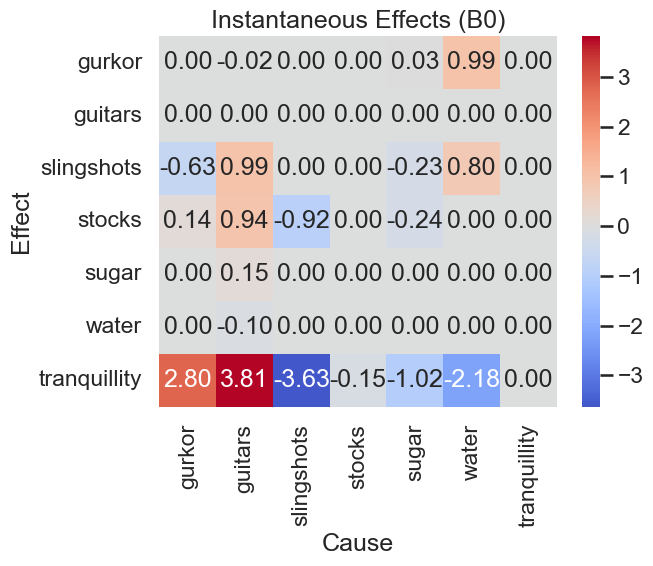

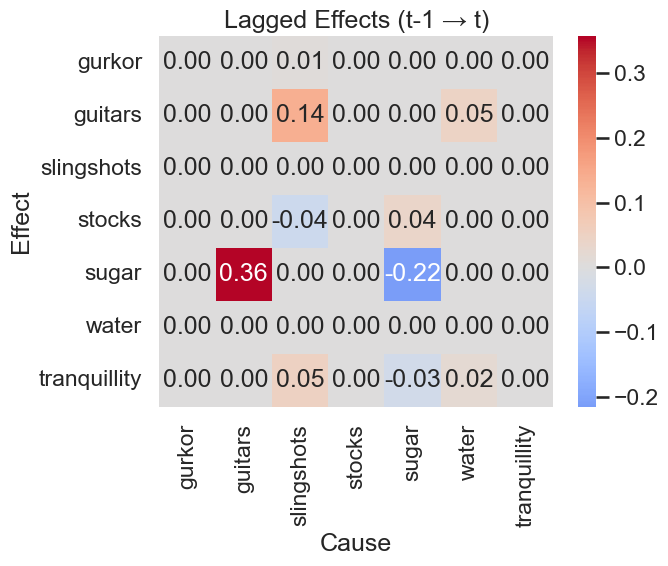

In [19]:
# Simple reduced-form VAR on simulated Y (lag 1 only for speed)
from lingam import VARLiNGAM

X = StandardScaler().fit_transform(df_sim.values)  # often helps
model = VARLiNGAM(lags=1, criterion='aic')     # or lags=2
model.fit(X)

def plot_heatmap(matrix, title, labels):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        xticklabels=labels,
        yticklabels=labels,
        cbar=True
    )
    plt.title(title)
    plt.xlabel("Cause")
    plt.ylabel("Effect")
    plt.tight_layout()
    plt.show()

labels = df_sim.columns
sns.set_theme(style="whitegrid", context="talk")

# Instantaneous
plot_heatmap(model.adjacency_matrices_[0], "Instantaneous Effects (B0)", labels)

# Lagged (lag 1)
plot_heatmap(model.adjacency_matrices_[1], "Lagged Effects (t-1 → t)", labels)

/Users/manswestman/project_financial_timeseries/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


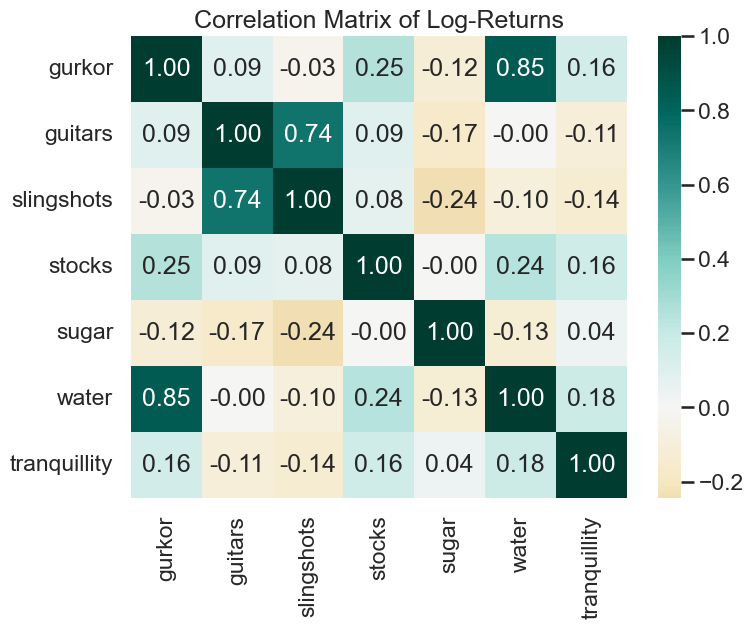

=============================== LOG RETURNS PCA ================================


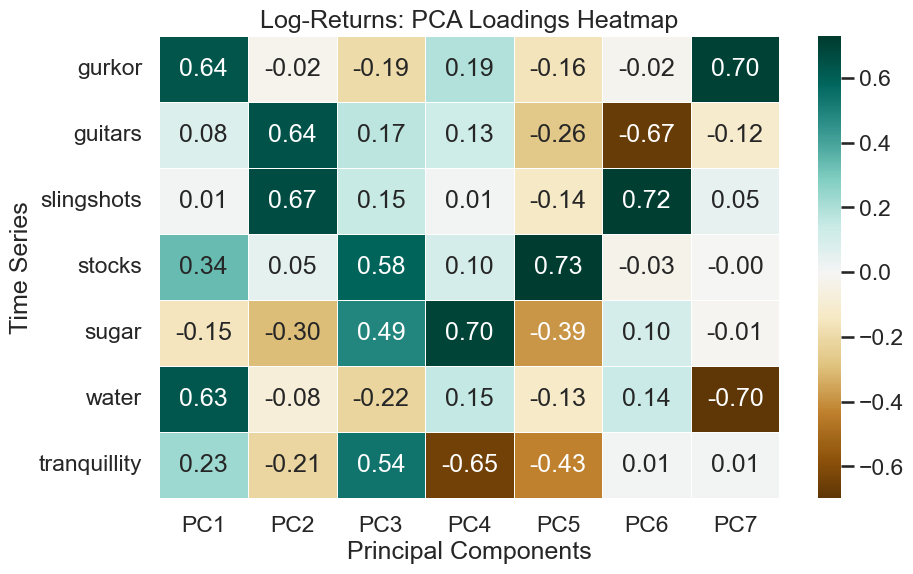

Explained Variance Ratio per Component:
PC1: 0.2966 (29.66%)
PC2: 0.2695 (26.95%)
PC3: 0.1448 (14.48%)
PC4: 0.1238 (12.38%)
PC5: 0.1089 (10.89%)
PC6: 0.0355 (3.55%)
PC7: 0.0208 (2.08%)

Cumulative Variance Explained by top 3 components: 71.09%


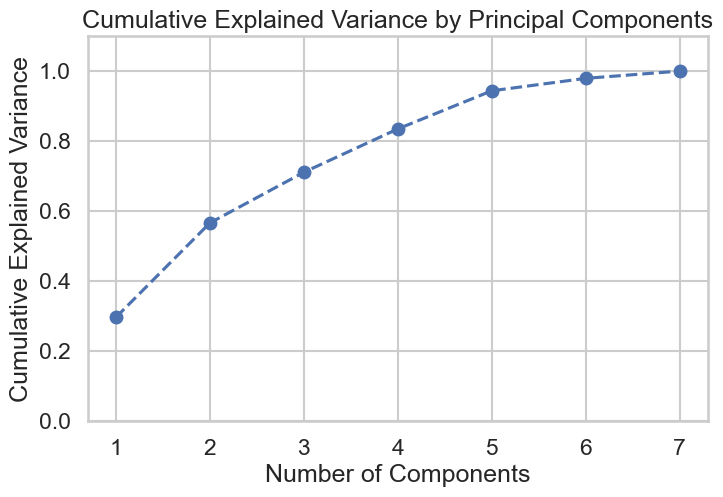

=== PRINCIPAL COMPONENT DRIVERS ===

PC1 is primarily driven by:
  gurkor          | Weight:  0.6353 | 🟢 Positive
  water           | Weight:  0.6325 | 🟢 Positive
  stocks          | Weight:  0.3358 | 🟢 Positive

PC2 is primarily driven by:
  slingshots      | Weight:  0.6653 | 🟢 Positive
  guitars         | Weight:  0.6416 | 🟢 Positive
  sugar           | Weight: -0.3010 | 🔴 Negative

PC3 is primarily driven by:
  stocks          | Weight:  0.5847 | 🟢 Positive
  tranquillity    | Weight:  0.5352 | 🟢 Positive
  sugar           | Weight:  0.4867 | 🟢 Positive


--- Log-Returns Variance Explained ---
Top 3 components explain: 71.09%

PCA Loadings (How much each series contributes to each PC):
                   PC1       PC2       PC3       PC4       PC5       PC6  \
gurkor        0.635319 -0.024875 -0.192414  0.191060 -0.159024 -0.021220   
guitars       0.079229  0.641598  0.166639  0.125280 -0.264835 -0.674320   
slingshots    0.006101  0.665324  0.147936  0.007183 -0.136915  0.717219 

In [20]:


# --- 1. DATA PREP ---

# Calculate Returns and align metadata
df_returns = np.log(df_sim / df_sim.shift(1)).dropna()

# --- 2. CORRELATION ANALYSIS ---
plt.figure(figsize=(8, 6))
sns.heatmap(df_returns.corr(), annot=True, cmap=THEME, center=0, fmt=".2f")
plt.title('Correlation Matrix of Log-Returns')
plt.show()

# --- 3. PCA FUNCTION ---
# Building a function keeps your code DRY (Don't Repeat Yourself) 
# and prevents variable overwriting.
def run_and_plot_pca(data, title_prefix):
    # Standardize
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # Fit PCA
    pca = PCA()
    pca.fit(scaled_data)
    
    # Loadings extraction
    loadings_df = pd.DataFrame(
        pca.components_.T, 
        columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
        index=data.columns
    )
    
    # Plot Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(loadings_df, annot=True, cmap=THEME, center=0, fmt=".2f", linewidths=0.5)
    plt.title(f'{title_prefix}: PCA Loadings Heatmap')
    plt.xlabel('Principal Components')
    plt.ylabel('Time Series')
    plt.show()

    # explained var
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    print("Explained Variance Ratio per Component:")
    for i, var in enumerate(explained_variance):
        print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

    print(f"\nCumulative Variance Explained by top 3 components: {cumulative_variance[2]*100:.2f}%")

    # Plot the Scree Plot
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 8), cumulative_variance, marker='o', linestyle='--')
    plt.title('Cumulative Explained Variance by Principal Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.ylim(0, 1.1)
    plt.show()

    print("=== PRINCIPAL COMPONENT DRIVERS ===")
    for pc in ['PC1', 'PC2', 'PC3']:
        print(f"\n{pc} is primarily driven by:")
        
        # Sort the features by their absolute contribution to this PC
        sorted_features = loadings_df[pc].abs().sort_values(ascending=False)
        
        for feature, abs_weight in sorted_features.items():
            actual_weight = loadings_df.loc[feature, pc]
            
            # Threshold: We only print features that have a meaningful impact (e.g., > 0.3)
            # Loadings are constrained between -1 and 1.
            if abs_weight > 0.25:
                direction = "🟢 Positive" if actual_weight > 0 else "🔴 Negative"
                print(f"  {feature:<15} | Weight: {actual_weight:>7.4f} | {direction}")

    print("\n" + "="*35 + "\n")
    
    # Variance Explained
    cumulative_var = np.cumsum(pca.explained_variance_ratio_)
    print(f"--- {title_prefix} Variance Explained ---")
    print(f"Top 3 components explain: {cumulative_var[2]*100:.2f}%\n")

    loadings = pd.DataFrame(
    pca.components_.T,  # Transpose the matrix
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_sim.columns # Your original 7 column names
)

    print("PCA Loadings (How much each series contributes to each PC):")
    print(loadings)
    
    return pca, loadings_df


print(80*"=")
print(f'{31* '='} LOG RETURNS PCA {32* '='}')
print(80*"=")
pca_returns, loadings_returns = run_and_plot_pca(df_returns, "Log-Returns")